# Scrap & Rework Agent
## Production Planning AI Agent System

**Model:** XGBoost Gradient Boosting Classifier  
**Purpose:** Real-time scrap risk scoring and root cause analysis  
**Alert Thresholds:** WARN >40% | ESCALATE >60%  

This notebook contains:
1. Synthetic data generation
2. Feature engineering
3. Model training (XGBoost)
4. Model evaluation
5. Model artifacts saving
6. Inference testing

In [17]:
import sys
!{sys.executable} -m pip install xgboost

## 1. Setup & Imports

In [18]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
from datetime import datetime, timedelta
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, 
    classification_report, 
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load Real Production Data from Database

In [20]:
# Load Real Production Data from Database
from pathlib import Path

# Load data from data directory
data_dir = Path('data')

# Load scrap quality inspection data (main dataset)
scrap_df = pd.read_csv(data_dir / 'scrap_quality_inspection.csv')
scrap_df['inspection_date'] = pd.to_datetime(scrap_df['inspection_date'])

# Load master data tables
machine_master = pd.read_csv(data_dir / 'machine_master.csv')
machine_master['last_calibration_date'] = pd.to_datetime(machine_master['last_calibration_date'])
machine_master['last_maintenance_date'] = pd.to_datetime(machine_master['last_maintenance_date'])

supplier_master = pd.read_csv(data_dir / 'supplier_master.csv')
material_master = pd.read_csv(data_dir / 'material_master.csv')

# Merge scrap data with machine master
df = scrap_df.merge(
    machine_master[['machine_id', 'machine_name', 'machine_type', 'last_calibration_date', 
                    'calibration_interval_days', 'last_maintenance_date', 'maintenance_interval_days']],
    on='machine_id',
    how='left'
)

# Merge with material master for material_group and unit_cost
df = df.merge(
    material_master[['material_no', 'material_group', 'unit_cost_eur', 'primary_supplier_id']],
    on='material_no',
    how='left'
)

# Merge with supplier master
df = df.merge(
    supplier_master[['supplier_id', 'supplier_name', 'otif_pct', 'scrap_contribution_pct', 
                     'rework_contribution_pct', 'risk_score_m5']].rename(columns={
        'scrap_contribution_pct': 'supplier_scrap_pct',
        'otif_pct': 'supplier_otif_pct',
        'risk_score_m5': 'supplier_risk_score'
    }),
    left_on='primary_supplier_id',
    right_on='supplier_id',
    how='left'
)

# Calculate calibration and maintenance lag days
current_date = pd.Timestamp('2026-04-10')  # Today's date
df['calibration_lag_days'] = (current_date - df['last_calibration_date']).dt.days
df['maintenance_lag_days'] = (current_date - df['last_maintenance_date']).dt.days

# Calculate overdue flags
df['calibration_overdue'] = (df['calibration_lag_days'] > df['calibration_interval_days']).astype(int)
df['maintenance_overdue'] = (df['maintenance_lag_days'] > df['maintenance_interval_days']).astype(int)

# Recalculate scrap_cost_eur using actual unit costs
df['scrap_cost_eur'] = df['scrap_qty'] * df['unit_cost_eur']

# Calculate rolling scrap rates (4-week rolling average by machine and shift)
df = df.sort_values('inspection_date')
df['rolling_scrap_4w_machine_id'] = df.groupby('machine_id')['scrap_rate_pct'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)
df['rolling_scrap_4w_shift'] = df.groupby('shift')['scrap_rate_pct'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

# Create additional features (estimated - replace with real data if available)
# Work centre utilization (estimated based on inspection frequency)
wc_inspection_freq = df.groupby('work_centre')['inspection_lot'].transform('count') / len(df)
df['wc_utilization'] = wc_inspection_freq * 100
df['wc_overload_prob'] = df['wc_utilization'].apply(lambda x: max(0, (x - 80) / 20) if x > 80 else 0)

# Order overload probability (estimated based on inspected quantities)
df['order_overload_prob'] = (df['inspected_qty'] - df['inspected_qty'].mean()) / df['inspected_qty'].std()
df['order_overload_prob'] = df['order_overload_prob'].clip(0, 1)

# Throughput deviation (estimated)
df['throughput_deviation_pct'] = ((df['inspected_qty'] - df.groupby('machine_id')['inspected_qty'].transform('mean')) / 
                                   df.groupby('machine_id')['inspected_qty'].transform('mean') * 100)

# Rename scrap_risk_probability to target_scrap_risk for consistency
df['target_scrap_risk'] = df['scrap_risk_probability']

# Fill missing values
df = df.fillna({
    'supplier_otif_pct': df['supplier_otif_pct'].mean(),
    'supplier_scrap_pct': df['supplier_scrap_pct'].mean(),
    'supplier_risk_score': df['supplier_risk_score'].mean(),
    'wc_utilization': 75.0,
    'wc_overload_prob': 0.0,
    'order_overload_prob': 0.0,
    'throughput_deviation_pct': 0.0
})

print(f'✅ Loaded {len(df)} real inspection records from database')
print(f'Date range: {df["inspection_date"].min()} to {df["inspection_date"].max()}')
print(f'Machines: {df["machine_id"].nunique()}, Materials: {df["material_no"].nunique()}')
print(f'Suppliers: {df["supplier_id"].nunique()}')
df.head()

✅ Loaded 237 real inspection records from database
Date range: 2026-01-05 00:00:00 to 2026-04-17 00:00:00
Machines: 11, Materials: 12
Suppliers: 10


,inspection_lot,production_order_no,material_no,work_centre,machine_id,shift,inspection_date,defect_type,defect_rate_pct,inspected_qty,scrap_qty,rework_qty,scrap_rate_pct,rework_rate_pct,scrap_risk_probability,scrap_cost_eur,action_taken,inspector_id,scenario,week_no,machine_name,machine_type,last_calibration_date,calibration_interval_days,last_maintenance_date,maintenance_interval_days,material_group,unit_cost_eur,primary_supplier_id,supplier_id,supplier_name,supplier_otif_pct,supplier_scrap_pct,rework_contribution_pct,supplier_risk_score,calibration_lag_days,maintenance_lag_days,calibration_overdue,maintenance_overdue,rolling_scrap_4w_machine_id,rolling_scrap_4w_shift,wc_utilization,wc_overload_prob,order_overload_prob,throughput_deviation_pct,target_scrap_risk
5,INS-3006,4706,M-5501,WC-01,MC-02,Afternoon,2026-01-05,Dimensional,4.61,191,6,3,3.14,1.57,0.20,1110.0,Pass,INS-02,NORMAL,1,CNC Lathe Unit 2,CNC Lathe,2026-02-18,90,2026-03-10,30,Precision Parts,185.0,SUP-09,SUP-09,Excellence Manufacturing,98,2.6,1.4,15,51,31,0,1,3.140,3.140,16.033755,0,1.0,53.333333,0.20
16,INS-3017,4717,M-4182,WC-15,MC-15,Afternoon,2026-01-05,Operator Error,3.17,30,1,1,3.33,3.33,0.20,15.9,Pass,INS-01,NORMAL,1,Surface Grinder 15,Surface Grinder,2026-03-25,90,2026-03-26,30,Composite Materials,15.9,SUP-05,SUP-05,Reliable Materials Group,97,3.2,1.8,18,16,15,0,0,3.330,3.235,17.721519,0,0.0,-72.368421,0.20
11,INS-3012,4712,M-3310,WC-04,MC-04,Morning,2026-01-06,Operator Error,2.92,197,6,3,3.05,1.52,0.08,134.4,Pass,INS-02,NORMAL,1,Hydraulic Press 4,Hydraulic Press,2026-03-06,90,2026-03-15,30,Fasteners & Fixings,22.4,SUP-12,SUP-12,FastTrack Supplies BV,96,3.5,1.9,20,35,26,0,0,3.050,3.050,13.924051,0,1.0,85.297030,0.08
1,INS-3002,4702,M-4182,WC-ASSM-03,MC-08,Morning,2026-01-06,Dimensional,6.30,84,5,3,5.95,3.57,0.26,79.5,Pass,INS-03,NORMAL,1,Assembly Station 8,Assembly,2026-02-05,90,2026-02-20,30,Composite Materials,15.9,SUP-05,SUP-05,Reliable Materials Group,97,3.2,1.8,18,64,49,0,1,5.950,4.500,12.236287,0,0.0,-17.451711,0.26
3,INS-3004,4704,M-6612,WC-01,MC-02,Night,2026-01-06,Material Fault,9.78,162,10,9,6.17,5.56,0.46,890.0,Rework,INS-02,NORMAL,1,CNC Lathe Unit 2,CNC Lathe,2026-02-18,90,2026-03-10,30,Electronic Components,89.0,SUP-18,SUP-18,Quality Components Inc,96,3.9,2.1,22,51,31,0,1,4.655,6.170,16.033755,0,1.0,30.052356,0.46


## 3. Create Target Variable & EDA

In [21]:
# Create binary target
df['target'] = (df['target_scrap_risk'] >= 0.40).astype(int)

print('Target distribution:')
print(df['target'].value_counts(normalize=True))
print(f'\nScrap risk probability stats:')
print(df['target_scrap_risk'].describe())

Target distribution:
target
1    0.506329
0    0.493671
Name: proportion, dtype: float64

Scrap risk probability stats:
count    237.000000
mean       0.432068
std        0.221754
min        0.080000
25%        0.260000
50%        0.400000
75%        0.570000
max        0.990000
Name: target_scrap_risk, dtype: float64


## 4. Feature Engineering

In [22]:
# Encoding maps
SHIFT_MAP = {'Morning': 0, 'Afternoon': 1, 'Night': 2}
DEFECT_MAP = {
    'Operator Error': 0, 'Dimensional': 1, 'Material Fault': 2,
    'Surface Finish': 3, 'Machine Setup': 4
}

# Apply encodings
df['shift_encoded'] = df['shift'].map(SHIFT_MAP).fillna(0)
df['defect_type_encoded'] = df['defect_type'].map(DEFECT_MAP).fillna(0)
df['machine_type_encoded'] = df['machine_type'].astype('category').cat.codes
df['material_group_encoded'] = df['material_group'].astype('category').cat.codes

# Engineered features
df['rework_share'] = df['rework_qty'] / (df['scrap_qty'] + df['rework_qty'] + 1e-6)
df['scrap_cost_per_unit'] = df['scrap_cost_eur'] / (df['inspected_qty'] + 1e-6)

print('✅ Feature engineering complete')

✅ Feature engineering complete


## 5. Train XGBoost Model

In [23]:
# Feature set
FEATURES = [
    'defect_rate_pct', 'scrap_rate_pct', 'rework_rate_pct',
    'defect_type_encoded', 'shift_encoded',
    'calibration_lag_days', 'maintenance_lag_days',
    'calibration_overdue', 'maintenance_overdue', 'machine_type_encoded',
    'supplier_otif_pct', 'supplier_scrap_pct', 'supplier_risk_score',
    'wc_utilization', 'wc_overload_prob', 'order_overload_prob',
    'throughput_deviation_pct', 'rolling_scrap_4w_machine_id',
    'rolling_scrap_4w_shift', 'material_group_encoded',
    'rework_share', 'scrap_cost_per_unit'
]

# Prepare data
X = df[FEATURES].fillna(0)
y = df['target']

# Time-based split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Train model
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    early_stopping_rounds=20,   # ← moved here
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('✅ Model trained')

Train: 189, Test: 48
✅ Model trained


## 6. Model Evaluation

AUC-ROC: 0.9919
Accuracy: 0.9375

              precision    recall  f1-score   support

          OK       0.88      0.93      0.90        15
     At Risk       0.97      0.94      0.95        33

    accuracy                           0.94        48
   macro avg       0.92      0.94      0.93        48
weighted avg       0.94      0.94      0.94        48



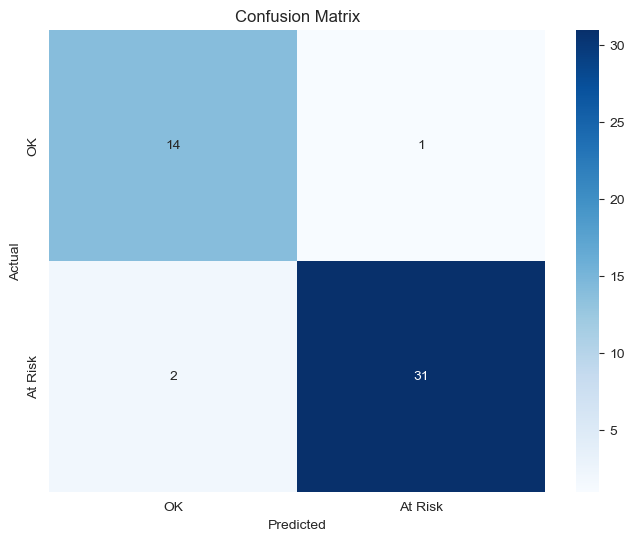

In [24]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
auc_roc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)

print(f'AUC-ROC: {auc_roc:.4f}')
print(f'Accuracy: {accuracy:.4f}\n')
print(classification_report(y_test, y_pred, target_names=['OK', 'At Risk']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['OK', 'At Risk'], yticklabels=['OK', 'At Risk'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 7. Feature Importance

Top 10 Most Important Features:
                    feature  importance
            defect_rate_pct    0.319382
             scrap_rate_pct    0.112020
            rework_rate_pct    0.110650
        supplier_risk_score    0.070832
        order_overload_prob    0.065966
     rolling_scrap_4w_shift    0.041983
        defect_type_encoded    0.039955
               rework_share    0.034325
        scrap_cost_per_unit    0.031155
rolling_scrap_4w_machine_id    0.023507


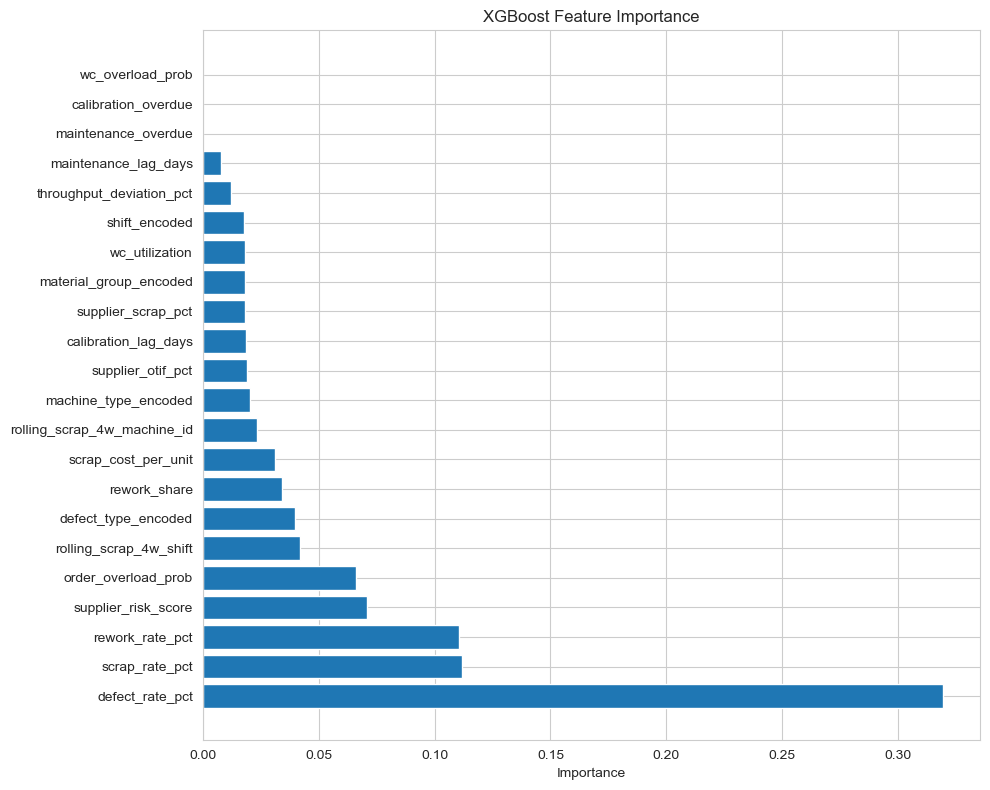

In [25]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 10 Most Important Features:')
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## 8. Save Model Artifacts

In [27]:
# Create models directory
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Save model
joblib.dump(model, models_dir / 'scrap_risk_m5.pkl')
joblib.dump(FEATURES, models_dir / 'scrap_risk_m5_features.pkl')

# Save encodings
encodings = {
    'shift_map': SHIFT_MAP,
    'defect_map': DEFECT_MAP,
    'machine_types': df['machine_type'].astype('category').cat.categories.tolist(),
    'material_groups': df['material_group'].astype('category').cat.categories.tolist()
}
joblib.dump(encodings, models_dir / 'scrap_risk_m5_encodings.pkl')

# Save metrics
metrics = {
    'auc_roc': float(auc_roc),
    'accuracy': float(accuracy),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'feature_count': len(FEATURES),
    'model_version': '1.0.0',
    'training_date': datetime.now().isoformat()
}

with open(models_dir / 'scrap_risk_m5_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'✅ All artifacts saved to {models_dir}/')
print(f'\nModel Performance:')
print(f'  AUC-ROC: {auc_roc:.4f}')
print(f'  Accuracy: {accuracy:.4f}')
print(f'\nNext: Deploy API with scrap_rework.py')

✅ All artifacts saved to models/

Model Performance:
  AUC-ROC: 0.9919
  Accuracy: 0.9375

Next: Deploy API with scrap_rework.py


## 9. Test Inference

In [28]:
# Test on a sample
sample_idx = 5
sample = X_test.iloc[sample_idx:sample_idx+1]
sample_raw = df.iloc[split_idx + sample_idx]

prob = model.predict_proba(sample)[0, 1]
alert_level = 'ESCALATE' if prob >= 0.60 else 'WARN' if prob >= 0.40 else 'OK'

print('SAMPLE INFERENCE TEST')
print('=' * 60)
print(f'Inspection Lot: {sample_raw["inspection_lot"]}')
print(f'Machine: {sample_raw["machine_id"]} | Shift: {sample_raw["shift"]}')
print(f'Scrap Rate: {sample_raw["scrap_rate_pct"]:.2f}%')
print(f'Calibration Overdue: {bool(sample_raw["calibration_overdue"])}')
print(f'\n🎯 PREDICTION:')
print(f'  Risk Probability: {prob:.4f} ({prob*100:.1f}%)')
print(f'  Alert Level: {alert_level}')
print(f'  True Label: {"At Risk" if y_test.iloc[sample_idx] == 1 else "OK"}')
print('=' * 60)

SAMPLE INFERENCE TEST
Inspection Lot: INS-3193
Machine: MC-02 | Shift: Night
Scrap Rate: 19.61%
Calibration Overdue: False

🎯 PREDICTION:
  Risk Probability: 0.9818 (98.2%)
  Alert Level: ESCALATE
  True Label: At Risk


In [32]:
# Train XGBoost Regressor for Scrap Percentage Prediction
X_reg = df[FEATURES].fillna(0)
y_reg = df['scrap_rate_pct']

# Use same 80/20 time-based split
X_reg_train, X_reg_test = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

print(f'Regression Train: {len(X_reg_train)}, Test: {len(X_reg_test)}')

# Train regressor
reg_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric='rmse',
    random_state=42
)

reg_model.fit(
    X_reg_train, y_reg_train,
    eval_set=[(X_reg_test, y_reg_test)],
    verbose=False
)

print('Successfully trained scrap percentage regressor')

Regression Train: 189, Test: 48
Successfully trained scrap percentage regressor


SCRAP PERCENTAGE REGRESSION METRICS
MAE:  0.2993%
RMSE: 0.6448%
R²:   0.9790


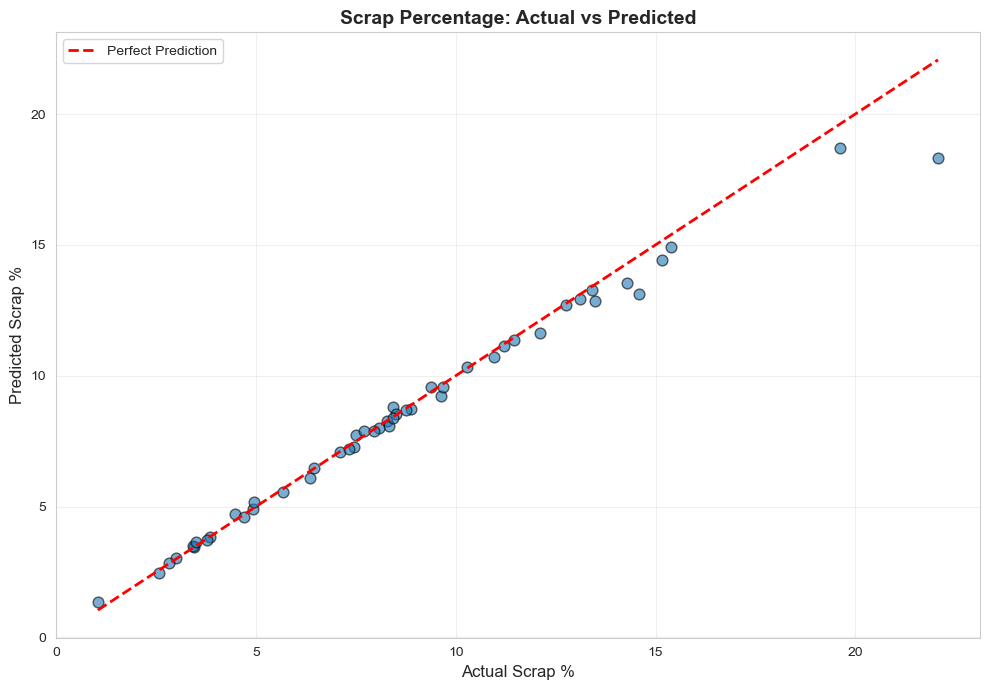

In [30]:
# Evaluate Regression Model
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_reg_pred = reg_model.predict(X_reg_test)

# Calculate metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print('SCRAP PERCENTAGE REGRESSION METRICS')
print('=' * 60)
print(f'MAE:  {mae:.4f}%')
print(f'RMSE: {rmse:.4f}%')
print(f'R²:   {r2:.4f}')
print('=' * 60)

# Plot Actual vs Predicted
plt.figure(figsize=(10, 7))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.6, edgecolors='k', s=60)
plt.plot([y_reg_test.min(), y_reg_test.max()], 
         [y_reg_test.min(), y_reg_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Scrap %', fontsize=12)
plt.ylabel('Predicted Scrap %', fontsize=12)
plt.title('Scrap Percentage: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# Combined Inference Function
def predict_scrap(sample_features):
    """
    Combined inference: scrap risk classification + scrap percentage regression
    
    Args:
        sample_features: DataFrame with feature columns
    
    Returns:
        dict with scrap_pct, risk_prob, alert_level, scrap_severity
    """
    # Classification: scrap risk probability
    risk_prob = model.predict_proba(sample_features)[0, 1]
    
    # Alert level
    if risk_prob >= 0.60:
        alert_level = 'ESCALATE'
    elif risk_prob >= 0.40:
        alert_level = 'WARN'
    else:
        alert_level = 'OK'
    
    # Regression: predicted scrap percentage
    scrap_pct = reg_model.predict(sample_features)[0]
    
    # Scrap severity flag
    if scrap_pct >= 10.0:
        scrap_severity = 'HIGH (Red)'
    elif scrap_pct >= 5.0:
        scrap_severity = 'MEDIUM (Yellow)'
    else:
        scrap_severity = 'LOW (Green)'
    
    return {
        'scrap_pct': scrap_pct,
        'risk_prob': risk_prob,
        'alert_level': alert_level,
        'scrap_severity': scrap_severity
    }

# Test on first test sample
test_sample = X_reg_test.iloc[0:1]
result = predict_scrap(test_sample)

print('COMBINED SCRAP PREDICTION')
print('=' * 60)
print(f'Predicted Scrap %:     {result["scrap_pct"]:.2f}%')
print(f'Risk Probability:      {result["risk_prob"]:.4f} ({result["risk_prob"]*100:.1f}%)')
print(f'Alert Level:           {result["alert_level"]}')
print(f'Scrap Severity:        {result["scrap_severity"]}')
print('=' * 60)
print(f'Actual Scrap %:        {y_reg_test.iloc[0]:.2f}%')
print(f'Actual Risk Label:     {"At Risk" if y_test.iloc[0] == 1 else "OK"}')

COMBINED SCRAP PREDICTION
Predicted Scrap %:     12.85%
Risk Probability:      0.9824 (98.2%)
Alert Level:           ESCALATE
Scrap Severity:        HIGH (Red)
Actual Scrap %:        13.48%
Actual Risk Label:     At Risk


In [33]:
# Save Regression Model for API
import joblib
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

joblib.dump(reg_model, models_dir / 'scrap_pct_regressor.pkl')
print(f'✓ Regression model saved to {models_dir / "scrap_pct_regressor.pkl"}')

✓ Regression model saved to models\scrap_pct_regressor.pkl
